### Guided DDPM and DDIM Density Experiments


This notebook is standalone: run cells from top to bottom.

In [ ]:
import time

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
from scipy.ndimage import distance_transform_edt

import jax

import jax.numpy as jnp

import jax.random as jr

jax.config.update("jax_enable_x64", True)

In [13]:
def create_curve_bounded_region(x_left, x_right, lower_curve_func, upper_curve_func):

    """Create a region bounded by two curves y=lower(x) and y=upper(x)."""



    def is_inside_vectorized(points):

        x_vals = points[:, 0]

        y_vals = points[:, 1]

        in_x_bounds = (x_vals >= x_left) & (x_vals <= x_right)

        y_lower_vals = lower_curve_func(x_vals)

        y_upper_vals = upper_curve_func(x_vals)

        in_y_bounds = (y_vals >= y_lower_vals) & (y_vals <= y_upper_vals)

        return jnp.logical_and(in_x_bounds, in_y_bounds)



    def y_lower(x):

        return lower_curve_func(x)



    def y_upper(x):

        return upper_curve_func(x)



    x_range = [x_left, x_right]

    return is_inside_vectorized, y_lower, y_upper, x_range
def create_left_crescent_constraints(center, radius_outer, radius_inner, offset_x):

    """Create a left-facing crescent (opens to the right)."""

    cx, cy = center[0], center[1]

    inner_cx = cx - offset_x

    inner_cy = cy



    def is_inside_vectorized(points):

        dist_outer_sq = jnp.sum((points - jnp.array([cx, cy])) ** 2, axis=1)

        in_outer = dist_outer_sq <= radius_outer**2

        dist_inner_sq = jnp.sum((points - jnp.array([inner_cx, inner_cy])) ** 2, axis=1)

        outside_inner = dist_inner_sq > radius_inner**2

        return in_outer & outside_inner



    def y_lower(x):

        x_rel_outer = x - cx

        under_sqrt_outer = jnp.maximum(radius_outer**2 - x_rel_outer**2, 0.0)

        return cy - jnp.sqrt(under_sqrt_outer)



    def y_upper(x):

        x_rel_outer = x - cx

        under_sqrt_outer = jnp.maximum(radius_outer**2 - x_rel_outer**2, 0.0)

        return cy + jnp.sqrt(under_sqrt_outer)



    x_range = [cx - radius_outer, cx + radius_outer]

    return is_inside_vectorized, y_lower, y_upper, x_range





def create_right_crescent_constraints(center, radius_outer, radius_inner, offset_x):

    """Create a right-facing crescent (opens to the left)."""

    cx, cy = center[0], center[1]

    inner_cx = cx + offset_x

    inner_cy = cy



    def is_inside_vectorized(points):

        dist_outer_sq = jnp.sum((points - jnp.array([cx, cy])) ** 2, axis=1)

        in_outer = dist_outer_sq <= radius_outer**2

        dist_inner_sq = jnp.sum((points - jnp.array([inner_cx, inner_cy])) ** 2, axis=1)

        outside_inner = dist_inner_sq > radius_inner**2

        return in_outer & outside_inner



    def y_lower(x):

        x_rel_outer = x - cx

        under_sqrt_outer = jnp.maximum(radius_outer**2 - x_rel_outer**2, 0.0)

        return cy - jnp.sqrt(under_sqrt_outer)



    def y_upper(x):

        x_rel_outer = x - cx

        under_sqrt_outer = jnp.maximum(radius_outer**2 - x_rel_outer**2, 0.0)

        return cy + jnp.sqrt(under_sqrt_outer)



    x_range = [cx - radius_outer, cx + radius_outer]

    return is_inside_vectorized, y_lower, y_upper, x_range





def create_circle_constraints(center, radius):

    """Create region helper functions for a disk."""

    cx, cy = center[0], center[1]



    def is_inside_vectorized(points):

        return jnp.sum((points - jnp.array(center)) ** 2, axis=1) <= radius**2



    def y_lower(x):

        delta_x = x - cx

        under_sqrt = jnp.maximum(radius**2 - delta_x**2, 0.0)

        return cy - jnp.sqrt(under_sqrt)



    def y_upper(x):

        delta_x = x - cx

        under_sqrt = jnp.maximum(radius**2 - delta_x**2, 0.0)

        return cy + jnp.sqrt(under_sqrt)



    x_range = [cx - radius, cx + radius]

    return is_inside_vectorized, y_lower, y_upper, x_range


In [14]:
def center_of_mass_fixed_grid(cur_pos, y_lower, y_upper, x_range, t, n_x=20, n_y=20, region=None):
    """Compute center of mass on a fixed grid, optionally over an arbitrary region mask."""
    lambda_t = jnp.exp(-t)
    sigma2_t = 1 - lambda_t**2

    if region is not None:
        x_min, x_max, y_min, y_max = region["bbox"]
        x_vals = jnp.linspace(x_min, x_max, n_x)
        y_vals = jnp.linspace(y_min, y_max, n_y)
        xx, yy = jnp.meshgrid(x_vals, y_vals, indexing="xy")
        points = jnp.stack([xx.ravel(), yy.ravel()], axis=1)

        diffs = points - cur_pos
        exponent = -0.5 * jnp.sum(diffs**2, axis=1) / sigma2_t
        phi_vals = jnp.exp(exponent) / (2 * jnp.pi * sigma2_t)
        mask = region["constraint"](points).astype(jnp.float64)
        weighted_phi = phi_vals * mask

        dx = (x_max - x_min) / jnp.maximum(n_x - 1, 1)
        dy = (y_max - y_min) / jnp.maximum(n_y - 1, 1)
        cell_area = dx * dy

        integral_phi = jnp.sum(weighted_phi) * cell_area
        integral_phi = jnp.where(integral_phi < 1e-300, 1.0, integral_phi)
        center_x = jnp.sum(points[:, 0] * weighted_phi) * cell_area / integral_phi
        center_y = jnp.sum(points[:, 1] * weighted_phi) * cell_area / integral_phi
        return jnp.array([center_x, center_y])

    x_min, x_max = x_range
    x_vals = jnp.linspace(x_min, x_max, n_x)

    def integrate_over_y(x):
        y_min = y_lower(x)
        y_max = y_upper(x)
        y_vals = jnp.linspace(y_min, y_max, n_y)

        def compute_phi_xyz(y):
            point = jnp.array([x, y])
            diff = point - cur_pos
            exponent = -0.5 * jnp.sum(diff**2) / sigma2_t
            phi_val = jnp.exp(exponent) / (2 * jnp.pi * sigma2_t)
            return jnp.array([phi_val, x * phi_val, y * phi_val])

        phi_xyz_vals = jax.vmap(compute_phi_xyz)(y_vals)
        return jnp.array([
            jax.scipy.integrate.trapezoid(phi_xyz_vals[:, 0], y_vals),
            jax.scipy.integrate.trapezoid(phi_xyz_vals[:, 1], y_vals),
            jax.scipy.integrate.trapezoid(phi_xyz_vals[:, 2], y_vals),
        ])

    integrals_x = jax.vmap(integrate_over_y)(x_vals)
    integral_phi = jax.scipy.integrate.trapezoid(integrals_x[:, 0], x_vals)
    integral_x_phi = jax.scipy.integrate.trapezoid(integrals_x[:, 1], x_vals)
    integral_y_phi = jax.scipy.integrate.trapezoid(integrals_x[:, 2], x_vals)
    integral_phi = jnp.where(integral_phi < 1e-300, 1.0, integral_phi)

    center_x = integral_x_phi / integral_phi
    center_y = integral_y_phi / integral_phi
    return jnp.array([center_x, center_y])


def lambda_func_fixed_grid(cur_pos, eta, t, y_lowers, y_uppers, x_ranges, weights, n_x=20, n_y=20, regions=None):
    """Compute lambda_eta using fixed-grid integration for each region."""
    lambda_t = jnp.exp(-t)
    sigma2_t = 1 - lambda_t**2
    n_regions = len(weights)

    def compute_integral_region(region_idx):
        if regions is not None:
            region = regions[region_idx]
            x_min, x_max, y_min, y_max = region["bbox"]
            x_vals = jnp.linspace(x_min, x_max, n_x)
            y_vals = jnp.linspace(y_min, y_max, n_y)
            xx, yy = jnp.meshgrid(x_vals, y_vals, indexing="xy")
            points = jnp.stack([xx.ravel(), yy.ravel()], axis=1)

            diffs = points - cur_pos
            exponent = -0.5 * jnp.sum(diffs**2, axis=1) / sigma2_t
            phi_vals = jnp.exp(exponent) / (2 * jnp.pi * sigma2_t)
            mask = region["constraint"](points).astype(jnp.float64)

            dx = (x_max - x_min) / jnp.maximum(n_x - 1, 1)
            dy = (y_max - y_min) / jnp.maximum(n_y - 1, 1)
            return jnp.sum(phi_vals * mask) * dx * dy

        x_min, x_max = x_ranges[region_idx]
        y_lower = y_lowers[region_idx]
        y_upper = y_uppers[region_idx]
        x_vals = jnp.linspace(x_min, x_max, n_x)

        def integrate_over_y(x):
            y_min = y_lower(x)
            y_max = y_upper(x)
            y_vals = jnp.linspace(y_min, y_max, n_y)

            def compute_phi(y):
                point = jnp.array([x, y])
                diff = point - cur_pos
                exponent = -0.5 * jnp.sum(diff**2) / sigma2_t
                return jnp.exp(exponent) / (2 * jnp.pi * sigma2_t)

            phi_vals = jax.vmap(compute_phi)(y_vals)
            return jax.scipy.integrate.trapezoid(phi_vals, y_vals)

        integrals_y = jax.vmap(integrate_over_y)(x_vals)
        return jax.scipy.integrate.trapezoid(integrals_y, x_vals)

    integrals = jnp.array([compute_integral_region(i) for i in range(n_regions)])
    weighted_integrals = weights * integrals
    integral_phi_eta = weighted_integrals[eta]
    integral_phi_total = jnp.sum(weighted_integrals)
    integral_phi_total = jnp.where(integral_phi_total < 1e-300, 1.0, integral_phi_total)
    return integral_phi_eta / integral_phi_total

In [15]:
def generate_grid(t0, T, delta, kappa):
    """Generate a time grid with
    - constant step kappa on [t0, T-1],
    - geometric steps kappa/(1+kappa)^m on [T-1, T-delta].

    The total number of steps is n_constant + n_tail.
    """
    t0 = float(t0)
    T = float(T)
    delta = float(delta)
    kappa = float(kappa)

    t_end = T - delta
    if t_end <= t0:
        return jnp.array([t0], dtype=jnp.float64)

    t_switch = min(t_end, max(t0, T - 1.0))
    n_constant = max(0, int(jnp.floor((t_switch - t0) / kappa)))

    t_after_constant = t0 + n_constant * kappa
    n_tail = 0
    t_probe = t_after_constant
    while t_probe < t_end:
        delta_k = kappa / ((1.0 + kappa) ** (n_tail + 1))
        t_probe += delta_k
        n_tail += 1

    num_steps = n_constant + n_tail

    ts = [t0]
    for k in range(num_steps):
        if k < n_constant:
            delta_k = kappa
        else:
            delta_k = kappa / ((1.0 + kappa) ** (k - n_constant + 1))

        t_next = ts[-1] + delta_k
        ts.append(min(t_next, t_end))

    return jnp.array(ts, dtype=jnp.float64)


def drift_vector_field(t, y, T, gamma, eta, y_lowers, y_uppers, x_ranges, weights, n_x=20, n_y=20, regions=None):
    """This defines the nonlinear part of the DDIM ODE."""
    weights_jax = jnp.array(weights, dtype=jnp.float64)
    n_regions = len(weights_jax)
    gamma_jax = jnp.array(gamma, dtype=jnp.float64)
    cur_pos = y
    time_remaining = T - t
    lambda_term = jnp.exp(-time_remaining)
    sigma2_term = 1 - lambda_term**2

    coms_list = []
    for i in range(n_regions):
        coms_list.append(
            center_of_mass_fixed_grid(
                cur_pos,
                None if regions is not None else y_lowers[i],
                None if regions is not None else y_uppers[i],
                None if regions is not None else x_ranges[i],
                time_remaining,
                n_x,
                n_y,
                region=None if regions is None else regions[i],
            )
        )
    coms = jnp.stack(coms_list)
    diffs = coms - (cur_pos / lambda_term)

    lambda_weights_list = []
    for i in range(n_regions):
        lambda_weights_list.append(
            lambda_func_fixed_grid(
                cur_pos,
                i,
                time_remaining,
                y_lowers,
                y_uppers,
                x_ranges,
                weights_jax,
                n_x,
                n_y,
                regions=regions,
            )
        )
    lambda_weights = jnp.array(lambda_weights_list)

    cur_diff = (gamma_jax * lambda_term / sigma2_term) * diffs[eta]
    average_diff = ((gamma_jax - 1) * lambda_term / sigma2_term) * jnp.sum(
        lambda_weights[:, jnp.newaxis] * diffs, axis=0
    )
    return cur_diff - average_diff


def DDIM_solver_exponential(
    gamma,
    eta,
    y_lowers,
    y_uppers,
    x_ranges,
    weights,
    initial_condition,
    T,
    ts,
    n_x=20,
    n_y=20,
    max_steps=16000,
    regions=None,
):
    """Solve one guided DDIM ODE trajectory using a JIT-compiled exponential scan."""
    ts_jax = jnp.array(ts, dtype=jnp.float64)
    n_steps = int(ts_jax.shape[0] - 1)
    if n_steps > max_steps:
        raise ValueError(f"Number of steps ({n_steps}) exceeds max_steps ({max_steps}).")

    t_prev = ts_jax[:-1]
    dt = ts_jax[1:] - ts_jax[:-1]
    exp_dt = jnp.exp(dt)
    exp_minus_one = jnp.expm1(dt)

    drift_fn = lambda t, y: drift_vector_field(
        t, y, T, gamma, eta, y_lowers, y_uppers, x_ranges, weights, n_x, n_y, regions=regions
    )

    @jax.jit
    def _integrate(y0, t_prev, exp_dt, exp_minus_one):
        def step(y, inputs):
            t_k, a_k, b_k = inputs
            f_val = drift_fn(t_k, y)
            y_next = a_k * y + b_k * f_val
            return y_next, y_next

        _, ys_tail = jax.lax.scan(step, y0, (t_prev, exp_dt, exp_minus_one))
        return jnp.concatenate([y0[jnp.newaxis, :], ys_tail], axis=0)

    y0 = jnp.array(initial_condition, dtype=jnp.float64)
    return _integrate(y0, t_prev, exp_dt, exp_minus_one)


def run_endpoints_ode(
    gamma,
    eta,
    y_lowers,
    y_uppers,
    x_ranges,
    weights,
    initial_conditions,
    T,
    ts,
    n_x=20,
    n_y=20,
    max_steps=16000,
    verbose=True,
    regions=None,
):
    """Run multiple DDIM ODE trajectories and return endpoints."""
    n_trajectories = initial_conditions.shape[0]

    if verbose:
        print(f"Running ODE with {n_trajectories} trajectories, γ={gamma}, η={eta}...")
        start_time = time.time()

    weights_jax = jnp.array(weights, dtype=jnp.float64)
    initial_conditions_jax = jnp.array(initial_conditions, dtype=jnp.float64)

    def solve_single(init_cond):
        traj = DDIM_solver_exponential(
            gamma=gamma,
            eta=eta,
            y_lowers=y_lowers,
            y_uppers=y_uppers,
            x_ranges=x_ranges,
            weights=weights_jax,
            initial_condition=init_cond,
            T=T,
            ts=ts,
            n_x=n_x,
            n_y=n_y,
            max_steps=max_steps,
            regions=regions,
        )
        return traj[-1]

    endpoints = jax.vmap(solve_single)(initial_conditions_jax)
    # endpoints_np = np.array(endpoints)

    # if verbose:
    #     total_time = time.time() - start_time
    #     print(f"✓ ODE done in {total_time:.1f}s  ({total_time/n_trajectories:.3f}s/trajectory)")

    return endpoints


def ddpm_endpoint_exp_direct(
    gamma,
    eta,
    y_lowers,
    y_uppers,
    x_ranges,
    weights,
    initial_condition,
    T,
    ts,
    random_key,
    n_x=20,
    n_y=20,
    regions=None,
):
    """Compute one DDPM endpoint directly from the exponential update (no diffrax)."""
    y0 = jnp.array(initial_condition, dtype=jnp.float64)
    ts_jax = jnp.array(ts, dtype=jnp.float64)
    n_steps = int(ts_jax.shape[0] - 1)
    t_prev = ts_jax[:-1]
    dt = ts_jax[1:] - ts_jax[:-1]

    exp_dt = jnp.exp(dt)
    exp_minus_one = jnp.expm1(dt)
    sqrt_exp_minus_one = jnp.sqrt(jnp.maximum(exp_minus_one, 0.0))

    weights_jax = jnp.array(weights, dtype=jnp.float64)
    normals = jax.random.normal(random_key, shape=(n_steps,) + y0.shape, dtype=y0.dtype)

    drift_fn = lambda t, y: 2 * drift_vector_field(
        t, y, T, gamma, eta, y_lowers, y_uppers, x_ranges, weights_jax, n_x, n_y, regions=regions
    )
    diffusion_fn = lambda t, y: jnp.sqrt(2.0) * jnp.ones_like(y)

    @jax.jit
    def _endpoint(y0, t_prev, exp_dt, exp_minus_one, sqrt_exp_minus_one, normals):
        def step(y, inputs):
            t_k, a_k, b_k, sqrt_b_k, z_k = inputs
            f_val = drift_fn(t_k, y)
            g_val = diffusion_fn(t_k, y)
            y_next = (a_k * y) + (b_k * f_val) + (sqrt_b_k * (g_val * z_k))
            return y_next, None

        yT, _ = jax.lax.scan(
            step, y0, (t_prev, exp_dt, exp_minus_one, sqrt_exp_minus_one, normals)
        )
        return yT

    return _endpoint(y0, t_prev, exp_dt, exp_minus_one, sqrt_exp_minus_one, normals)


def run_endpoints_sde(
    gamma,
    eta,
    y_lowers,
    y_uppers,
    x_ranges,
    weights,
    initial_conditions,
    T,
    ts,
    n_x=20,
    n_y=20,
    max_steps=16000,
    seed=1234,
    verbose=True,
    regions=None,
):
    """Run multiple DDPM SDE trajectories and return endpoints."""
    _ = max_steps
    n_trajectories = initial_conditions.shape[0]

    if verbose:
        print(f"Running SDE with {n_trajectories} trajectories, γ={gamma}, η={eta}...")
        start_time = time.time()

    initial_conditions_jax = jnp.array(initial_conditions, dtype=jnp.float64)
    keys = jax.random.split(seed, n_trajectories)

    def solve_single(key, init_cond):
        return ddpm_endpoint_exp_direct(
            gamma=gamma,
            eta=eta,
            y_lowers=y_lowers,
            y_uppers=y_uppers,
            x_ranges=x_ranges,
            weights=weights,
            initial_condition=init_cond,
            T=T,
            ts=ts,
            random_key=key,
            n_x=n_x,
            n_y=n_y,
            regions=regions,
        )

    endpoints = jax.vmap(solve_single)(keys, initial_conditions_jax)
    # endpoints_np = np.array(endpoints)

    # if verbose:
    #     total_time = time.time() - start_time
    #     print(f"✓ SDE done in {total_time:.1f}s  ({total_time/n_trajectories:.3f}s/trajectory)")

    return endpoints

In [16]:
def _draw_region_overlays(ax, regions, xx, yy, masks):
    """Draw dashed boundaries and labels for regions on an axes."""
    region_labels = ['I', 'II', 'III', 'IV', 'V']

    for mask in masks:
        ax.contour(
            xx, yy, mask.astype(float),
            levels=[0.5],
            colors=['black'],
            linestyles='dashed',
            linewidths=1.5,
            zorder=3,
        )

    for region_idx, (region, mask) in enumerate(zip(regions, masks), start=1):
        x_left, x_right, y_bottom, y_top = region['bbox']
        x_target = 0.5 * (x_left + x_right)
        y_target = 0.5 * (y_bottom + y_top)

        if not np.any(mask):
            continue

        distance_map = distance_transform_edt(mask)
        max_distance = np.max(distance_map)
        candidate_pixels = np.argwhere(distance_map == max_distance)

        y_idx = candidate_pixels[:, 0]
        x_idx = candidate_pixels[:, 1]
        x_candidates = xx[y_idx, x_idx]
        y_candidates = yy[y_idx, x_idx]
        distances_sq = (x_candidates - x_target) ** 2 + (y_candidates - y_target) ** 2
        best_idx = np.argmin(distances_sq)

        label_x = x_candidates[best_idx]
        label_y = y_candidates[best_idx]

        ax.text(
            label_x,
            label_y,
            region_labels[region_idx - 1],
            ha='center',
            va='center',
            fontsize=16,
            fontweight='black',
            color='black',
            zorder=4,
        )


def plot_empirical_densities_single_eta(endpoints, regions, plot_extent, eta=None,
                                       ax=None, resolution=250, point_size=4,
                                       point_alpha=0.2, color='blue'):
    """
    Plot empirical density (scatter plot) for endpoints of a single eta.

    Parameters:
    -----------
    endpoints : array-like, shape (n_samples, 2)
        The endpoint coordinates from trajectories.
    regions : list of dict
        Each dict should have 'constraint' (callable) and 'bbox' keys.
    plot_extent : list [x_min, x_max, y_min, y_max]
        Plot bounds.
    eta : int or None
        Label for the eta value (optional, used in title).
    ax : matplotlib.axes.Axes or None
        Axes to plot on. If None, creates a new figure.
    resolution : int
        Resolution for region mask grid (default 250).
    point_size : float
        Scatter plot point size (default 4).
    point_alpha : float
        Scatter plot point alpha (default 0.2).
    color : str
        Color for scatter points (default 'blue').

    Returns:
    --------
    ax : matplotlib.axes.Axes
        The axes object with the plot.
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5), dpi=150, facecolor='white')

    ax.set_facecolor('white')

    x_min, x_max, y_min, y_max = plot_extent

    # Plot scatter points
    endpoints_np = np.asarray(endpoints)
    ax.scatter(
        endpoints_np[:, 0],
        endpoints_np[:, 1],
        s=point_size,
        alpha=point_alpha,
        c=color,
        edgecolors='none',
        rasterized=True,
        zorder=1,
    )

    # Build region mask cache
    x_grid = np.linspace(x_min, x_max, resolution)
    y_grid = np.linspace(y_min, y_max, resolution)
    xx, yy = np.meshgrid(x_grid, y_grid)
    grid_points = np.column_stack([xx.ravel(), yy.ravel()])

    masks = [
        np.asarray(region['constraint'](grid_points)).reshape(xx.shape)
        for region in regions
    ]

    # Draw region overlays
    _draw_region_overlays(ax=ax, regions=regions, xx=xx, yy=yy, masks=masks)

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    if eta is not None:
        ax.set_title(f'$\\eta={eta}$')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    return ax

### 5-Region Density Computation

In [17]:
# 5-region geometry setup
T_5r = 5
delta_5r = 0.001
kappa_5r = 0.1
ts_5r = generate_grid(t0=0.0, T=T_5r, delta=delta_5r, kappa=kappa_5r)

weights_5r = jnp.array([0.2, 0.2, 0.2, 0.2, 0.2], dtype=jnp.float64)

lower_curve_5r = lambda x: -0.5 * (x + 3) ** 2 * (x + 1) ** 2
upper_curve_5r = lambda x: 0.5 * (x + 3) ** 2 * (x + 1) ** 2

is_region0_5r, y_lower0_5r, y_upper0_5r, x_range0_5r = create_curve_bounded_region(
    x_left=-3.0,
    x_right=-1.0,
    lower_curve_func=lower_curve_5r,
    upper_curve_func=upper_curve_5r,
)

is_region1_5r, y_lower1_5r, y_upper1_5r, x_range1_5r = create_left_crescent_constraints(
    center=jnp.array([2.0, 2.0]),
    radius_outer=1.5,
    radius_inner=1.0,
    offset_x=0.8,
)

is_region2_5r, y_lower2_5r, y_upper2_5r, x_range2_5r = create_right_crescent_constraints(
    center=jnp.array([2.0, -2.0]),
    radius_outer=1.5,
    radius_inner=1.0,
    offset_x=0.8,
)

is_region3_5r, y_lower3_5r, y_upper3_5r, x_range3_5r = create_circle_constraints(
    center=jnp.array([-3.0, 3.0]),
    radius=0.8,
)

is_region4_5r, y_lower4_5r, y_upper4_5r, x_range4_5r = create_circle_constraints(
    center=jnp.array([-1.0, -3.0]),
    radius=0.8,
)

y_lowers_5r = [y_lower0_5r, y_lower1_5r, y_lower2_5r, y_lower3_5r, y_lower4_5r]
y_uppers_5r = [y_upper0_5r, y_upper1_5r, y_upper2_5r, y_upper3_5r, y_upper4_5r]
x_ranges_5r = [x_range0_5r, x_range1_5r, x_range2_5r, x_range3_5r, x_range4_5r]

regions_5r = [
    {'constraint': is_region0_5r, 'bbox': [x_range0_5r[0], x_range0_5r[1], -0.6, 0.6]},
    {'constraint': is_region1_5r, 'bbox': [x_range1_5r[0], x_range1_5r[1], 0.5, 3.5]},
    {'constraint': is_region2_5r, 'bbox': [x_range2_5r[0], x_range2_5r[1], -3.5, -0.5]},
    {'constraint': is_region3_5r, 'bbox': [x_range3_5r[0], x_range3_5r[1], 2.2, 3.8]},
    {'constraint': is_region4_5r, 'bbox': [x_range4_5r[0], x_range4_5r[1], -3.8, -2.2]},
]

x_min = min(r['bbox'][0] for r in regions_5r) - 0.5
x_max = max(r['bbox'][1] for r in regions_5r) + 0.5
y_min = min(r['bbox'][2] for r in regions_5r) - 0.5
y_max = max(r['bbox'][3] for r in regions_5r) + 0.5
plot_extent_5r = [x_min, x_max, y_min, y_max]

print('5-region setup ready.')

5-region setup ready.


In [ ]:
n_trajectories_5r = 100
# eta_5r = 0
etas_mixture = [0, 1, 2, 3, 4]
gammas_5r = [1, 1.5, 2, 5]

key_5r = jr.PRNGKey(20260310)
key_5r, subkey_5r = jr.split(key_5r)
initial_conditions_5r = jr.normal(subkey_5r, shape=(n_trajectories_5r, 2))

In [30]:
def single_run_ode(eta, gamma):
    return run_endpoints_ode(
        gamma=gamma,
        eta=eta,
        y_lowers=y_lowers_5r,
        y_uppers=y_uppers_5r,
        x_ranges=x_ranges_5r,
        weights=weights_5r,
        initial_conditions=initial_conditions_5r,
        T=T_5r,
        ts=ts_5r,
        n_x=20,
        n_y=20,
        max_steps=16000,
        verbose=False,     # Disable side effects
        regions=regions_5r,
    )

vmap_gamma_ode = jax.vmap(single_run_ode, in_axes=(None, 0))

vmap_both_ode = jax.vmap(vmap_gamma_ode, in_axes=(0, None))

fast_ode_batch = jax.jit(vmap_both_ode)

# 4. Execute the fully vectorized operations
endpoints_ode_5r = fast_ode_batch(jnp.array(etas_mixture), jnp.array(gammas_5r))

In [31]:
gammas_array = jnp.array(gammas_5r)
etas_array = jnp.array(etas_mixture)

# 1. Generate the array of keys outside the function using vmap
seed_ints = 20260310 + jnp.astype(gammas_array * 100, jnp.int32)
keys_array = jax.vmap(jax.random.PRNGKey)(seed_ints)

# 2. Update the wrapper to accept the pre-generated key
def single_run_sde(eta, gamma, key):
    return run_endpoints_sde(
        gamma=gamma,
        eta=eta,
        y_lowers=y_lowers_5r,
        y_uppers=y_uppers_5r,
        x_ranges=x_ranges_5r,
        weights=weights_5r,
        initial_conditions=initial_conditions_5r,
        T=T_5r,
        ts=ts_5r,
        n_x=20,
        n_y=20,
        max_steps=16000,
        seed=key,          # Pass the pre-generated JAX key directly
        verbose=False,
        regions=regions_5r,
    )

# 3. Adjust the in_axes mapping
# Inner vmap: maps over gamma (axis 0) and keys (axis 0). eta is unmapped (None).
vmap_gamma_sde = jax.vmap(single_run_sde, in_axes=(None, 0, 0))

# Outer vmap: maps over eta (axis 0). gammas and keys are unmapped at this level (None).
vmap_both_sde = jax.vmap(vmap_gamma_sde, in_axes=(0, None, None))

fast_sde_batch = jax.jit(vmap_both_sde)

# 4. Execute
endpoints_sde_5r = fast_sde_batch(etas_array, gammas_array, keys_array)


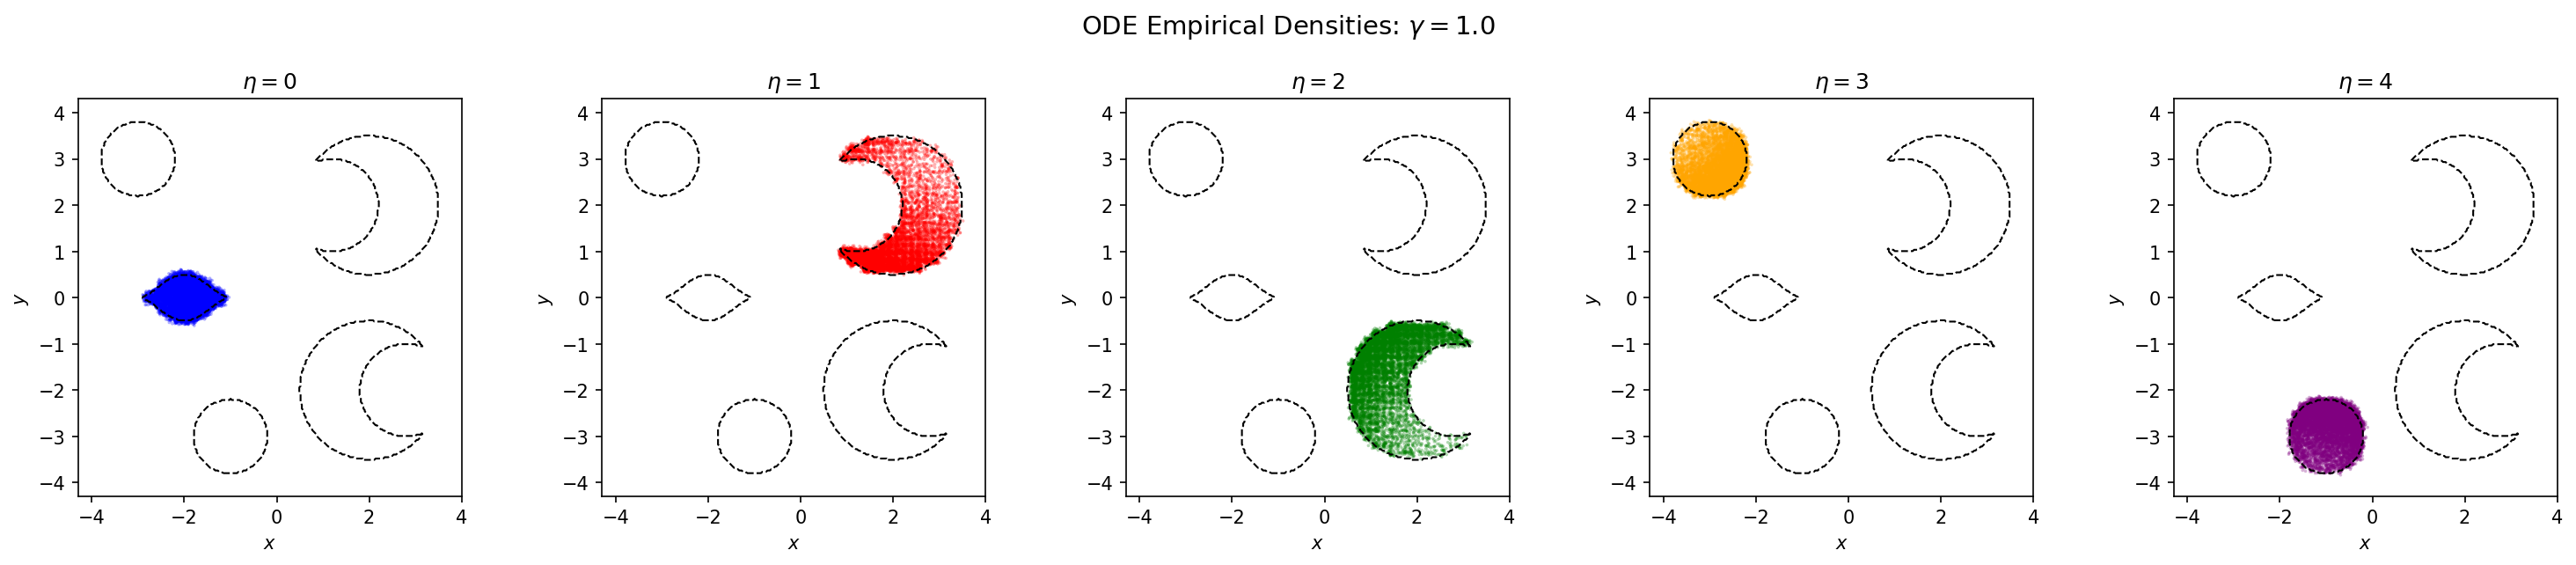

✓ Visualization complete for γ=1.0


In [32]:
### Visualization: Empirical Densities

# Plot empirical densities for a selected gamma value, showing all etas
gamma_to_plot = 1.0  # Change this to any gamma in gammas_5r

base_colors = ['blue', 'red', 'green', 'orange', 'purple']

gamma_idx = gammas_5r.index(gamma_to_plot)

# Precompute region masks once (reused across all subplots)
x_min, x_max, y_min, y_max = plot_extent_5r
x_grid = np.linspace(x_min, x_max, 300)
y_grid = np.linspace(y_min, y_max, 300)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])
masks = [
    np.asarray(region['constraint'](grid_points)).reshape(xx.shape)
    for region in regions_5r
]

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4), dpi=150, facecolor='white')

for eta_idx, eta in enumerate(etas_mixture):
    endpoints_ode = np.asarray(endpoints_ode_5r[eta_idx, gamma_idx])

    ax = axes[eta_idx]
    ax.set_facecolor('white')

    ax.scatter(
        endpoints_ode[:, 0],
        endpoints_ode[:, 1],
        s=3,
        alpha=0.3,
        c=base_colors[eta],
        edgecolors='none',
        rasterized=True,
        zorder=1,
    )

    for mask in masks:
        ax.contour(
            xx, yy, mask.astype(float),
            levels=[0.5],
            colors=['black'],
            linestyles='dashed',
            linewidths=1.0,
            zorder=3,
        )

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'$\\eta={eta}$')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')

fig.suptitle(f'ODE Empirical Densities: $\\gamma={gamma_to_plot}$', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\u2713 Visualization complete for \u03b3={gamma_to_plot}')

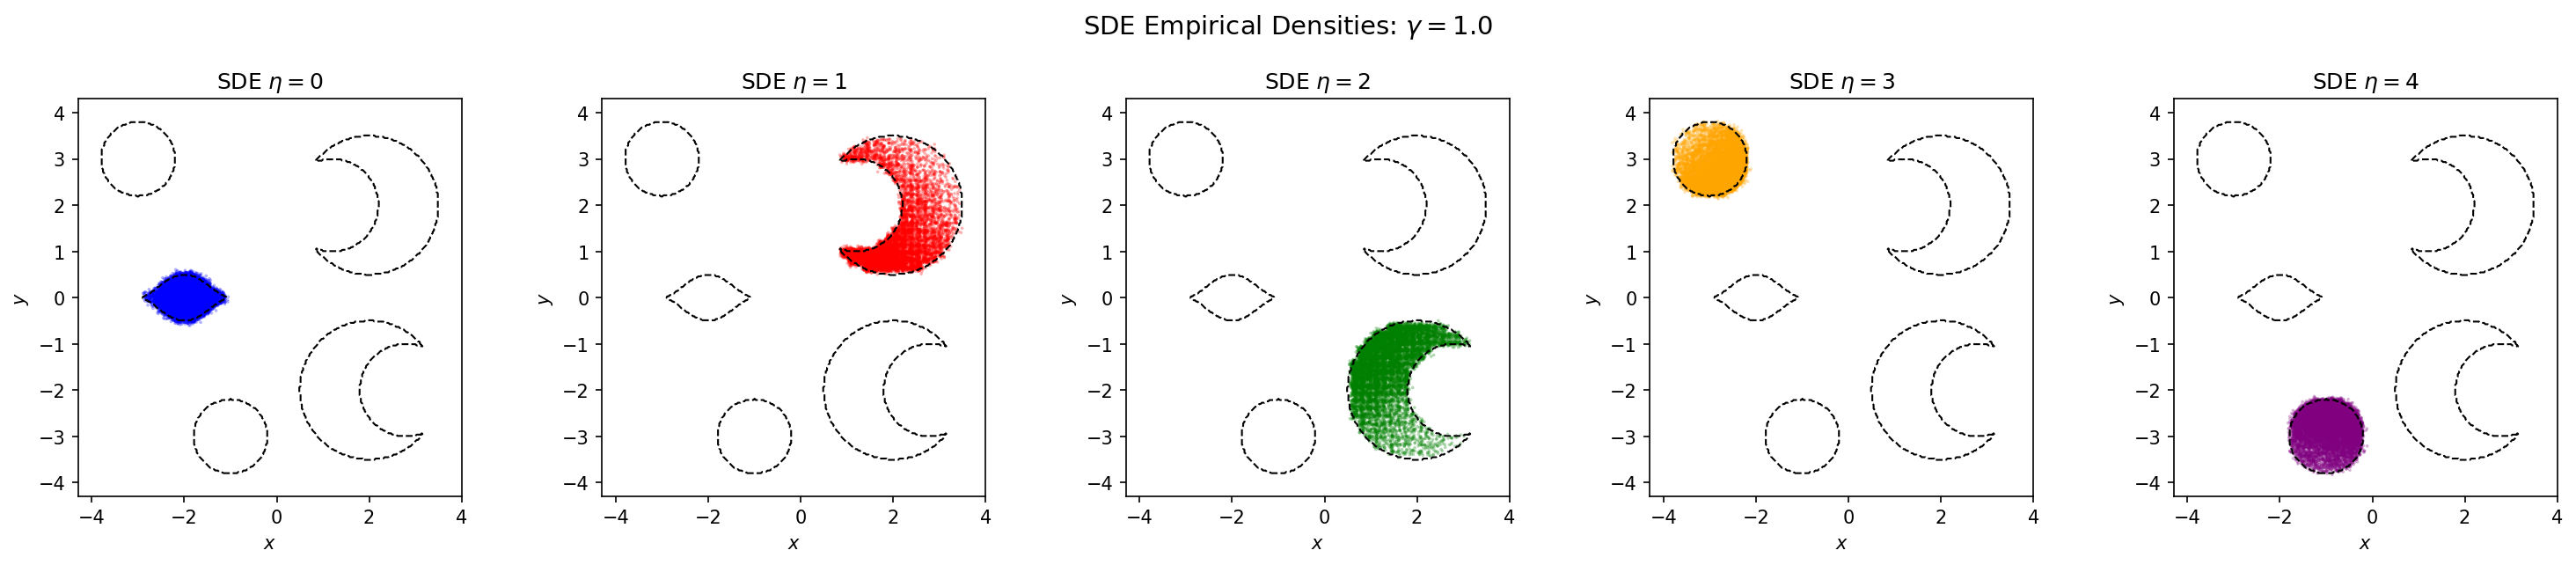

✓ SDE Visualization complete for γ=1.0


In [33]:
### Visualization: SDE Empirical Densities

# Plot empirical densities for a selected gamma value from the SDE runs
gamma_to_plot_sde = 1.0

base_colors = ['blue', 'red', 'green', 'orange', 'purple']
gamma_idx = gammas_5r.index(gamma_to_plot_sde)

# Re-use or define plot extent
x_min, x_max, y_min, y_max = plot_extent_5r
x_grid = np.linspace(x_min, x_max, 300)
y_grid = np.linspace(y_min, y_max, 300)
xx, yy = np.meshgrid(x_grid, y_grid)
grid_points = np.column_stack([xx.ravel(), yy.ravel()])
masks = [
    np.asarray(region['constraint'](grid_points)).reshape(xx.shape)
    for region in regions_5r
]

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20, 4), dpi=150, facecolor='white')

for eta_idx, eta in enumerate(etas_mixture):
    # Extract SDE endpoints for this specific (eta, gamma)
    endpoints_sde = np.asarray(endpoints_sde_5r[eta_idx, gamma_idx])

    ax = axes[eta_idx]
    ax.set_facecolor('white')

    ax.scatter(
        endpoints_sde[:, 0],
        endpoints_sde[:, 1],
        s=3,
        alpha=0.3,
        c=base_colors[eta],
        edgecolors='none',
        rasterized=True,
        zorder=1,
    )

    # Plot region boundaries
    for mask in masks:
        ax.contour(
            xx, yy, mask.astype(float),
            levels=[0.5],
            colors=['black'],
            linestyles='dashed',
            linewidths=1.0,
            zorder=3,
        )

    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
    ax.set_title(f'SDE $\\eta={eta}$')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_aspect('equal')

fig.suptitle(f'SDE Empirical Densities: $\\gamma={gamma_to_plot_sde}$', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f'\u2713 SDE Visualization complete for \u03b3={gamma_to_plot_sde}')